Saving image.jp2 to image (3).jp2


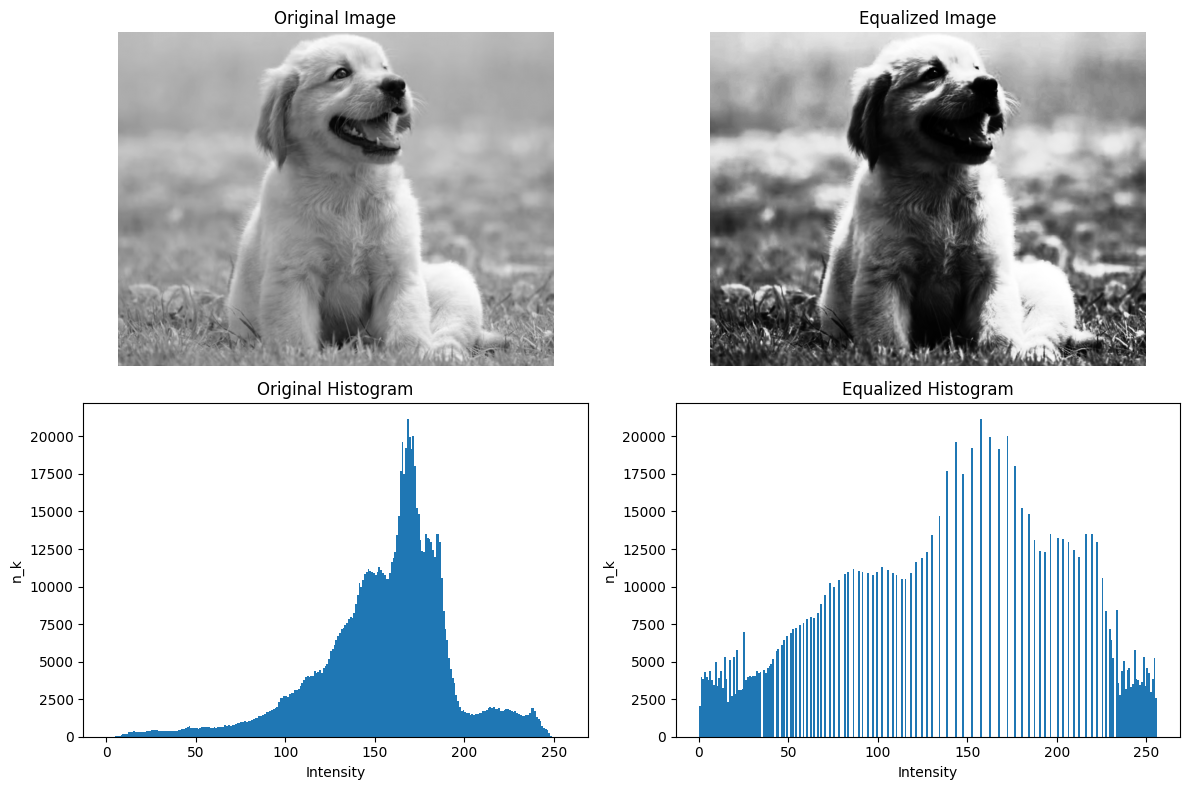

Intensity (r_k) | n_k | p_r(r_k) | CDF | s_k
-------------------------------------------------------
4  |  4  |  4e-06  |  4e-06  |  0
5  |  15  |  1.5e-05  |  1.8e-05  |  0
6  |  36  |  3.5e-05  |  5.3e-05  |  0
7  |  36  |  3.5e-05  |  8.8e-05  |  0
8  |  107  |  0.000103  |  0.000191  |  0
9  |  160  |  0.000155  |  0.000346  |  0
10  |  186  |  0.00018  |  0.000526  |  0
11  |  197  |  0.00019  |  0.000717  |  0
12  |  323  |  0.000312  |  0.001029  |  0
13  |  293  |  0.000283  |  0.001312  |  0
14  |  316  |  0.000306  |  0.001618  |  0
15  |  348  |  0.000336  |  0.001954  |  0
16  |  336  |  0.000325  |  0.002279  |  1
17  |  319  |  0.000308  |  0.002588  |  1
18  |  312  |  0.000302  |  0.002889  |  1
19  |  326  |  0.000315  |  0.003204  |  1
20  |  305  |  0.000295  |  0.003499  |  1
21  |  337  |  0.000326  |  0.003825  |  1
22  |  381  |  0.000368  |  0.004194  |  1
23  |  366  |  0.000354  |  0.004548  |  1
24  |  409  |  0.000395  |  0.004943  |  1
25  |  417  |  0.0004

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
filename = next(iter(uploaded))

# Read image in grayscale
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# Number of pixels
M, N = img.shape
total_pixels = M * N

# Calculate histogram n_k
histogram = np.zeros(256, dtype=int)

for pixel in img.flatten():
    histogram[pixel] += 1

# Probability p_r(r_k) = n_k / (M*N)
probability = histogram / total_pixels

# Calculate CDF
cdf = np.cumsum(probability)

# Transformation function
L = 256
transformation = np.round((L - 1) * cdf).astype(np.uint8)

# Create equalized image
equalized_img = transformation[img]

# Display original and equalized images
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(equalized_img, cmap="gray")
plt.title("Equalized Image")
plt.axis("off")

# Original histogram
plt.subplot(2, 2, 3)
plt.hist(img.flatten(), bins=256, range=[0, 256])
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("n_k")

# Equalized histogram
plt.subplot(2, 2, 4)
plt.hist(equalized_img.flatten(), bins=256, range=[0, 256])
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("n_k")

plt.tight_layout()
plt.show()

# Display histogram table
print("Intensity (r_k) | n_k | p_r(r_k) | CDF | s_k")
print("-" * 55)

for k in range(256):
    if histogram[k] > 0:
        print(
            k, " | ",
            histogram[k], " | ",
            round(probability[k], 6), " | ",
            round(cdf[k], 6), " | ",
            transformation[k]
        )

ques 2

Upload INPUT image:


Saving image.jp2 to image (5).jp2
Upload REFERENCE image:


Saving reference.jpg to reference.jpg


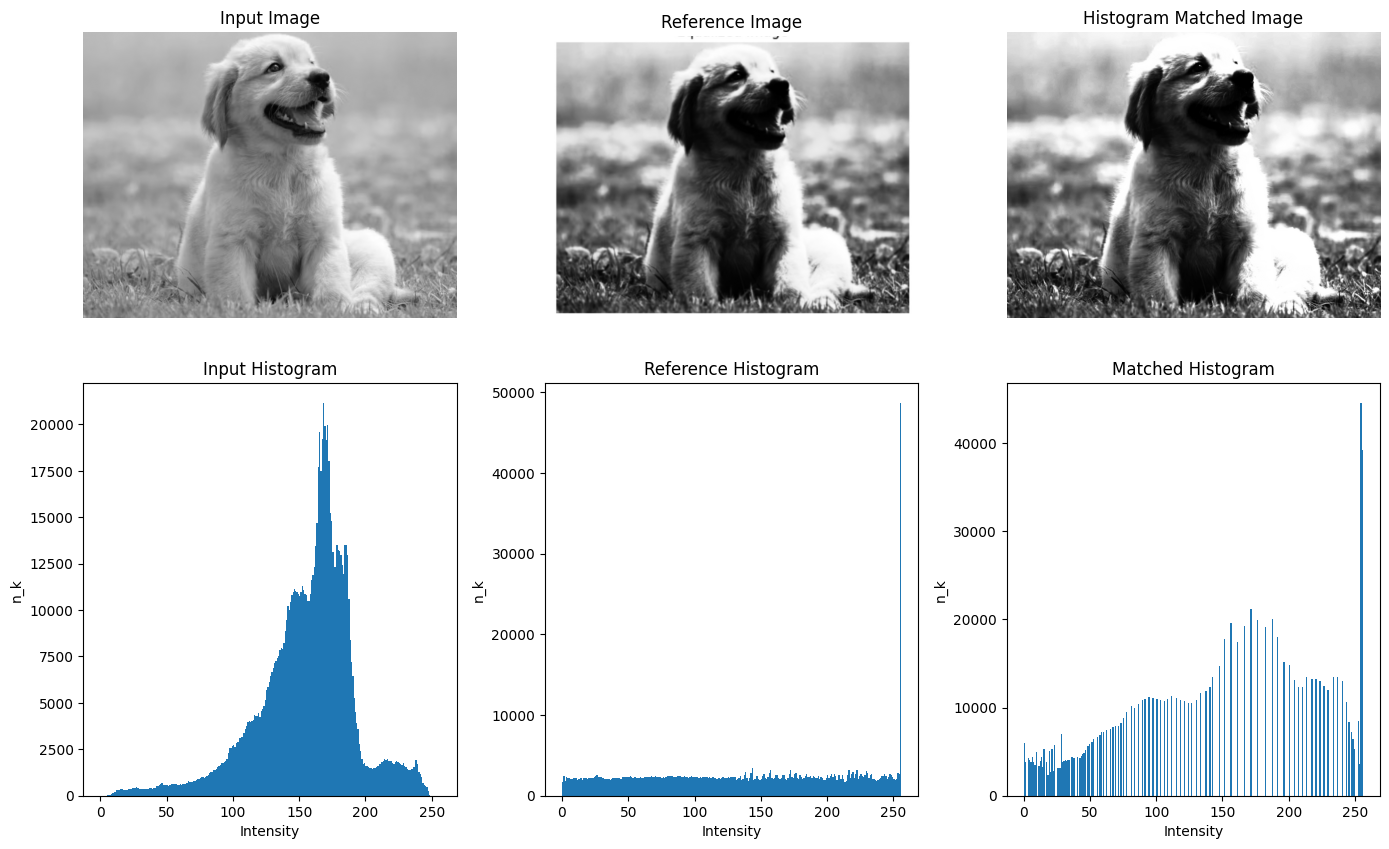


Intensity | Input CDF | Input Equalized | Reference Equalized | Mapping
---------------------------------------------------------------------------
4  |  4e-06  |  0  |  1  |  0
5  |  1.8e-05  |  0  |  1  |  0
6  |  5.3e-05  |  0  |  1  |  0
7  |  8.8e-05  |  0  |  1  |  0
8  |  0.000191  |  0  |  1  |  0
9  |  0.000346  |  0  |  1  |  0
10  |  0.000526  |  0  |  1  |  0
11  |  0.000717  |  0  |  1  |  0
12  |  0.001029  |  0  |  1  |  0
13  |  0.001312  |  0  |  1  |  0
14  |  0.001618  |  0  |  1  |  0
15  |  0.001954  |  0  |  1  |  0
16  |  0.002279  |  1  |  1  |  0
17  |  0.002588  |  1  |  1  |  0
18  |  0.002889  |  1  |  1  |  0
19  |  0.003204  |  1  |  1  |  0
20  |  0.003499  |  1  |  1  |  0
21  |  0.003825  |  1  |  1  |  0
22  |  0.004194  |  1  |  1  |  0
23  |  0.004548  |  1  |  1  |  0
24  |  0.004943  |  1  |  1  |  0
25  |  0.005346  |  1  |  1  |  0
26  |  0.00577  |  1  |  1  |  0
27  |  0.006226  |  2  |  2  |  1
28  |  0.006638  |  2  |  2  |  1
29  |  0.00699

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files



print("Upload INPUT image:")
uploaded_input = files.upload()
input_filename = next(iter(uploaded_input))



print("Upload REFERENCE image:")
uploaded_reference = files.upload()
reference_filename = next(iter(uploaded_reference))

# Read both images in grayscale
input_img = cv2.imread(input_filename, cv2.IMREAD_GRAYSCALE)
reference_img = cv2.imread(reference_filename, cv2.IMREAD_GRAYSCALE)

# Check images
if input_img is None or reference_img is None:
    print("Error: Could not read the images.")
else:



    hist_input = np.zeros(256, dtype=int)

    for pixel in input_img.flatten():
        hist_input[pixel] += 1

    prob_input = hist_input / input_img.size


    cdf_input = np.cumsum(prob_input)

    L = 256
    s_input = np.round((L - 1) * cdf_input).astype(np.uint8)



    hist_reference = np.zeros(256, dtype=int)

    for pixel in reference_img.flatten():
        hist_reference[pixel] += 1


    prob_reference = hist_reference / reference_img.size


    cdf_reference = np.cumsum(prob_reference)


    s_reference = np.round(
        (L - 1) * cdf_reference
    ).astype(np.uint8)



    mapping = np.zeros(256, dtype=np.uint8)

    for i in range(256):


        difference = np.abs(
            s_reference.astype(int) - int(s_input[i])
        )

        mapping[i] = np.argmin(difference)




    matched_img = mapping[input_img]



    plt.figure(figsize=(14, 9))

    # Input image
    plt.subplot(2, 3, 1)
    plt.imshow(input_img, cmap="gray")
    plt.title("Input Image")
    plt.axis("off")

    # Reference image
    plt.subplot(2, 3, 2)
    plt.imshow(reference_img, cmap="gray")
    plt.title("Reference Image")
    plt.axis("off")

    # Matched image
    plt.subplot(2, 3, 3)
    plt.imshow(matched_img, cmap="gray")
    plt.title("Histogram Matched Image")
    plt.axis("off")

    # Input histogram
    plt.subplot(2, 3, 4)
    plt.hist(input_img.flatten(), bins=256, range=[0, 256])
    plt.title("Input Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("n_k")

    # Reference histogram
    plt.subplot(2, 3, 5)
    plt.hist(reference_img.flatten(), bins=256, range=[0, 256])
    plt.title("Reference Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("n_k")

    # Matched histogram
    plt.subplot(2, 3, 6)
    plt.hist(matched_img.flatten(), bins=256, range=[0, 256])
    plt.title("Matched Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("n_k")

    plt.tight_layout()
    plt.show()


    # ========================================================
    # STEP 6: Display transformation table
    # ========================================================

    print("\nIntensity | Input CDF | Input Equalized | Reference Equalized | Mapping")
    print("-" * 75)

    for i in range(256):

        if hist_input[i] > 0:

            print(
                i,
                " | ",
                round(cdf_input[i], 6),
                " | ",
                s_input[i],
                " | ",
                s_reference[mapping[i]],
                " | ",
                mapping[i]
            )